# Application Report: Master Data Science Data Analysis
**Author:** Mohamed Waleed Elmogy  
**Email:** mohammed.elmogy7500@gmail.com  
**Date:** June 2026  
**Institution:** TU Dortmund University - M.Sc. Data Science Application

## 1. Introduction and Data Preparation
This notebook analyzes the performance of 486 students in Mathematics and Language. Additional variables include gender and parental level of education (measured on an ordinal scale: high school, associate's degree, bachelor's degree, master's degree). Both test scores range from 0 to 100.

The first step is to load the dataset, handle the European decimal formatting (commas instead of periods), and reshape the data from a "long" format into a "wide" format so each student has a single row.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [25]:
# 1. Load the data
# The CSV uses a semicolon ';' separator and a comma ',' for decimals.
df = pd.read_csv('Scores.csv', sep=';', decimal=',')

In [26]:
# Drop the first empty unnamed column (index column from the CSV)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [27]:
# 2. Reshape the data from Long to Wide format
# We want one row per student with 'math' and 'language' as separate columns
df_wide = df.pivot(
    index=['student_id', 'gender', 'parental.level.of.education'], 
    columns='subject', 
    values='score'
).reset_index()

In [28]:
# Ensure the ordinal nature of parental education is preserved in categorical form
education_order = ["high school", "associate's degree", "bachelor's degree", "master's degree"]
df_wide['parental.level.of.education'] = pd.Categorical(
    df_wide['parental.level.of.education'], 
    categories=education_order, 
    ordered=True
)

df_wide.head()

subject,student_id,gender,parental.level.of.education,language,math
0,id_001,female,high school,40.0,23.0
1,id_002,female,high school,80.5,68.0
2,id_003,male,high school,81.0,82.0
3,id_004,female,high school,60.5,58.0
4,id_005,female,high school,69.0,60.0


## 2. Descriptive Analysis
In this section, we perform a detailed descriptive analysis of the data set to understand the location and dispersion of the scores. 

### Mathematical Definitions
* **Arithmetic Mean (Location):** $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$
* **Sample Standard Deviation (Dispersion):** $s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}$
* **Median:** The value separating the higher half from the lower half of a data sample.

We will calculate these statistics for both subjects grouped by Gender and Parental Level of Education, followed by statistical graphics (boxplots) to visually inspect differences and outliers.

In [29]:
# Descriptive Statistics by Gender
desc_gender = df_wide.groupby('gender')[['math', 'language']].agg(['mean', 'median', 'std', 'min', 'max'])
print("Descriptive Statistics by Gender:")
display(desc_gender)

Descriptive Statistics by Gender:


subject       math                                  language         \
              mean median        std   min    max       mean median   
gender                                                                
female   63.857143   64.0  15.261921  23.0  100.0  73.004082   73.0   
male     68.946058   70.0  14.425137  30.0  100.0  64.931535   65.5   

subject                          
               std   min    max  
gender                           
female   14.012508  29.5  100.0  
male     13.752291  19.5  100.0

In [30]:
# Descriptive Statistics by Parental Education
desc_edu = df_wide.groupby('parental.level.of.education')[['math', 'language']].agg(['mean', 'median', 'std', 'count'])
print("\nDescriptive Statistics by Parental Level of Education:")
display(desc_edu)


Descriptive Statistics by Parental Level of Education:


subject                           math                           language  \
                                  mean median        std count       mean   
parental.level.of.education                                                 
high school                  62.243590   63.0  14.036989   156  63.532051   
associate's degree           67.813559   66.0  15.244382   177  70.022599   
bachelor's degree            68.436170   67.0  15.048708    94  72.058511   
master's degree              69.745763   73.0  15.153915    59  75.525424   

subject                                              
                            median        std count  
parental.level.of.education                          
high school                   65.0  13.398685   156  
associate's degree            72.0  14.214951   177  
bachelor's degree             73.0  14.267200    94  
master's degree               76.0  13.554304    59

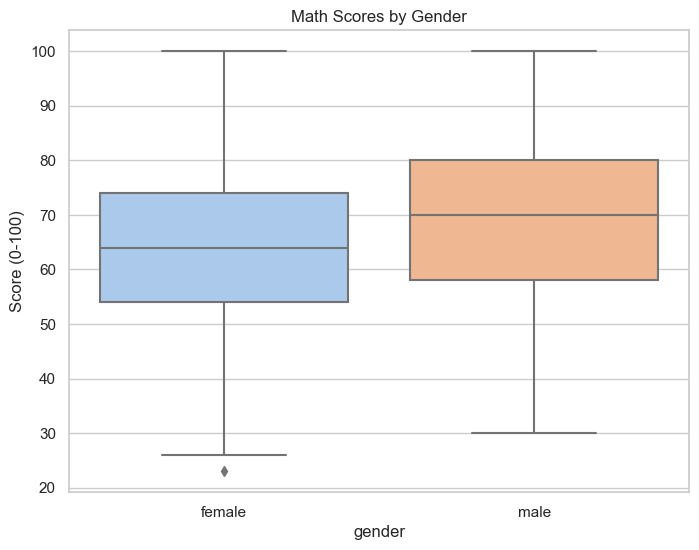

In [31]:
# Set the visual style for seaborn
sns.set_theme(style="whitegrid")

# Math Scores by Gender
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_wide, x='gender', y='math', palette="pastel")
plt.title('Math Scores by Gender')
plt.ylabel('Score (0-100)')
plt.show()

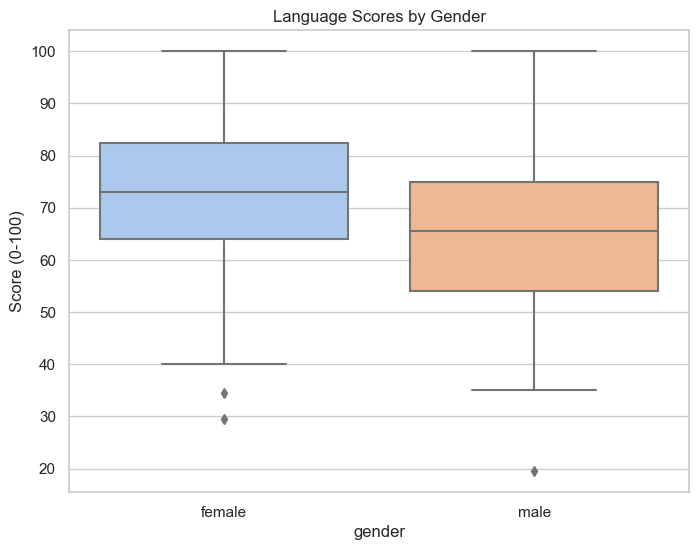

In [32]:
# Language Scores by Gender
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_wide, x='gender', y='language', palette="pastel")
plt.title('Language Scores by Gender')
plt.ylabel('Score (0-100)')
plt.show()

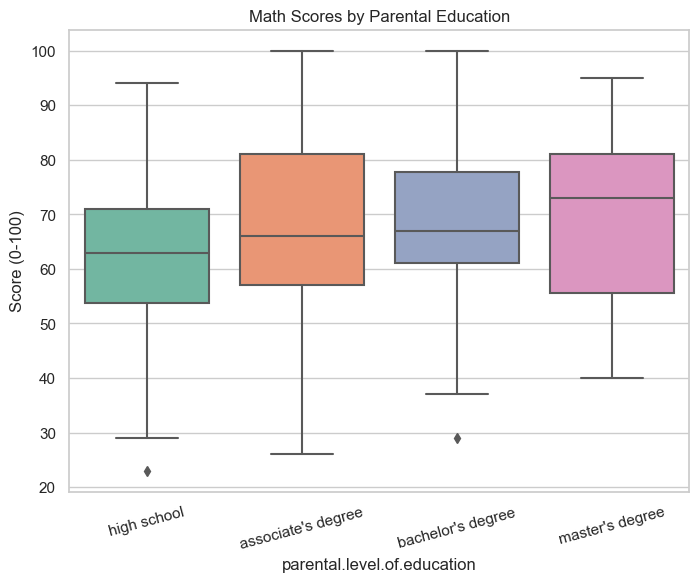

In [33]:
# Math Scores by Parental Education
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_wide, x='parental.level.of.education', y='math', palette="Set2")
plt.title('Math Scores by Parental Education')
plt.xticks(rotation=15)
plt.ylabel('Score (0-100)')
plt.show()

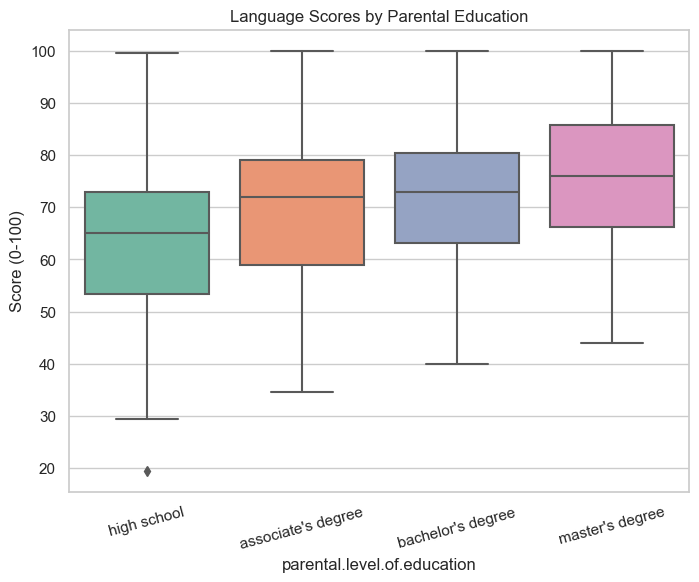

In [34]:
# Language Scores by Parental Education
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_wide, x='parental.level.of.education', y='language', palette="Set2")
plt.title('Language Scores by Parental Education')
plt.xticks(rotation=15)
plt.ylabel('Score (0-100)')
plt.show()

## 3. Hypothesis Testing: Gender Differences
**Research Question 1:** Is there a statistically significant difference between male and female students in their Mathematics scores and in their Language scores?

### Choice of Test
We will compare the means of two independent groups (Male vs. Female). 
1.  **Assumptions:** We must first test for normality (Shapiro-Wilk test) and equality of variances (Levene's test).
2.  **Test Selection:** * If assumptions are met, we use the **Independent Two-Sample t-test**: $t = \frac{\bar{x}_1 - \bar{x}_2}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$
    * If variances are unequal, we use **Welch's t-test**. 
    * If normality is strongly violated, we use the non-parametric **Mann-Whitney U test**. However, given our large sample size ($N=486$), the t-test is generally robust due to the Central Limit Theorem.

In [40]:
def check_assumptions_and_test(group1, group2, variable_name):
    print(f"--- Testing for {variable_name} ---")
    
    # 1. Normality Check (Shapiro-Wilk)
    # H0: Data is normally distributed
    stat1, p1 = stats.shapiro(group1)
    stat2, p2 = stats.shapiro(group2)
    print(f"Shapiro-Wilk p-values: Group 1 = {p1:.4f}, Group 2 = {p2:.4f}")
    
    # 2. Variance Check (Levene's Test)
    # H0: Variances are equal
    stat_lev, p_lev = stats.levene(group1, group2)
    print(f"Levene's Test p-value: {p_lev:.4f}")
    
    # 3. Choose and execute appropriate test
    if p_lev > 0.05:
        print("Variances are equal. Performing standard independent t-test.")
        stat_t, p_t = stats.ttest_ind(group1, group2, equal_var=True)
    else:
        print("Variances are unequal. Performing Welch's t-test.")
        stat_t, p_t = stats.ttest_ind(group1, group2, equal_var=False)
        
    print(f"Test Statistic: {stat_t:.4f}, P-value: {p_t:.4f}\n")

# Extract arrays
math_male = df_wide[df_wide['gender'] == 'male']['math'].dropna()
math_female = df_wide[df_wide['gender'] == 'female']['math'].dropna()

lang_male = df_wide[df_wide['gender'] == 'male']['language'].dropna()
lang_female = df_wide[df_wide['gender'] == 'female']['language'].dropna()

In [41]:
# Run tests
check_assumptions_and_test(math_male, math_female, 'Mathematics')

--- Testing for Mathematics ---
Shapiro-Wilk p-values: Group 1 = 0.0505, Group 2 = 0.5010
Levene's Test p-value: 0.9382
Variances are equal. Performing standard independent t-test.
Test Statistic: 3.7765, P-value: 0.0002



In [43]:
# Run tests
check_assumptions_and_test(lang_male, lang_female, 'Language')

--- Testing for Language ---
Shapiro-Wilk p-values: Group 1 = 0.1389, Group 2 = 0.0853
Levene's Test p-value: 0.6897
Variances are equal. Performing standard independent t-test.
Test Statistic: -6.4087, P-value: 0.0000



## 4. Hypothesis Testing: Parental Education Differences
**Research Question 2:** Is there a difference in scores across parental education levels? If so, which groups differ from each other?

### Choice of Test
Because we are comparing more than two independent groups across a single continuous variable, the appropriate method is **One-Way ANOVA (Analysis of Variance)**. 
* **ANOVA Formula (F-statistic):** $F = \frac{\text{Between-Group Variance}}{\text{Within-Group Variance}}$
* **Post-Hoc Analysis:** If the ANOVA is significant ($p < 0.05$), it tells us that *at least one* group differs, but not *which* groups. We will use **Tukey's HSD (Honestly Significant Difference)** test to perform pairwise comparisons while controlling for the family-wise error rate.

In [37]:
def run_anova_and_posthoc(df, subject):
    print(f"--- ANOVA for {subject.capitalize()} Scores ---")
    
    # Drop NaNs for the specific test
    df_clean = df.dropna(subset=[subject, 'parental.level.of.education'])
    
    # Run One-Way ANOVA
    model = ols(f"{subject} ~ C(Q('parental.level.of.education'))", data=df_clean).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("ANOVA Results:")
    display(anova_table)
    
    # Check significance
    p_val = anova_table['PR(>F)'][0]
    if p_val < 0.05:
        print("\nANOVA is significant. Performing Tukey HSD Post-Hoc Test:")
        tukey = pairwise_tukeyhsd(endog=df_clean[subject], 
                                  groups=df_clean['parental.level.of.education'], 
                                  alpha=0.05)
        print(tukey.summary())
    else:
        print("\nANOVA is not significant. No post-hoc test needed.")
    print("\n" + "="*60 + "\n")

In [44]:
# Run ANOVA and Post-Hoc for Mathematics Scores
run_anova_and_posthoc(df_wide, 'math')

--- ANOVA for Math Scores ---
ANOVA Results:


,sum_sq,df,F,PR(>F)
C(Q('parental.level.of.education')),4098.683680,3.0,6.222926,0.000375
Residual,105821.894509,482.0,NaN,NaN



ANOVA is significant. Performing Tukey HSD Post-Hoc Test:
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------




In [45]:
# Run ANOVA and Post-Hoc for Language Scores
run_anova_and_posthoc(df_wide, 'language')

--- ANOVA for Language Scores ---
ANOVA Results:


,sum_sq,df,F,PR(>F)
C(Q('parental.level.of.education')),8240.860082,3.0,14.24059,6.617864e-09
Residual,92975.889404,482.0,NaN,NaN



ANOVA is significant. Performing Tukey HSD Post-Hoc Test:
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.0359 0.6596  -2.5337  6.6055  False
associate's degree       high school  -6.4905 0.0001 -10.4226 -2.5585   True
associate's degree   master's degree   5.5028 0.0429   0.1202 10.8854   True
 bachelor's degree       high school  -8.5265    0.0 -13.2016 -3.8514   True
 bachelor's degree   master's degree   3.4669 0.4365  -2.4802   9.414  False
       high school   master's degree  11.9934    0.0    6.521 17.4658   True
----------------------------------------------------------------------------


